In [36]:
%load_ext autoreload
%autoreload 2

from IPython.display import display, Markdown
from datasets import load_dataset, Dataset
from dotenv import load_dotenv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
load_dotenv()

import sys
sys.path.append("../..")
from src.utils.vlm_utils import display_image

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [45]:
analysis_df = pd.read_json('../data/analysis_results.jsonl', lines=True).set_index('slug')
ocr_df =  pd.read_json('../data/ocr_results.jsonl', lines=True).set_index('slug')
sourceforge_df = pd.read_json('../data/sourceforge_projects.jsonl', lines=True).set_index('slug')[['title']]
merged_df = sourceforge_df.join(analysis_df).join(ocr_df).dropna().assign(length = lambda x : x['ocr'].apply(len))

In [46]:
merged_df

,title,image_description,keywords,category,ocr,length
slug,,,,,,
boot-repair,boot-repair,"The screenshot shows a window titled ""Boot Rep...","[Boot Repair, boot repair tool, Recommended re...",system utilities,# Boot Repair\n\n## Repair the boot of the com...,224
codeblocks,Code::Blocks,The screenshot shows the Code::Blocks IDE with...,"[Code::Blocks, C++, terrain.cpp, PGF, Plugin F...",code editor,# Code::Blocks - Test Framework\n\n## Project ...,213
crystaldiskinfo,CrystalDiskInfo,The screenshot displays the CrystalDiskInfo ap...,"[CrystalDiskInfo, SSD, Samsung 990 PRO, NVMe, ...",system utilities,```markdown\n# CrystalDiskInfo 9.0.0 x64\n\n##...,254
hwinfo,HWiNFO,The screenshot displays the HWiNFO application...,"[HWiNFO, hardware monitoring, Intel Core i7-47...",system utilities,# HWiNFO64 v5.91-3551\n\n## System Summary\n\n...,1793
keepass,KeePass,"The screenshot displays the ""Options"" window o...","[KeePass, Options, Interface settings, Auto-Ty...",system utilities,# Options\nHere you can configure the global K...,922
...,...,...,...,...,...,...
youtube-vanced-pc,YouTube Vanced PC,"The screenshot displays a window titled ""YouTu...","[YouTube Vanced, QR code, Android, premium fea...",video streaming,# YOUTUBE VANCED\n\nPLEASE SCAN QR CODE BELOW!...,339
zbar.mirror,ZBar,The screenshot displays a terminal-like interf...,"[ZBar, barcode, terminal, dbus-monitor, code-1...",terminal,"In order to test if dbus is working, you could...",51
zekr,Zekr: Multimedia Quran Study Software,"The screenshot shows the Zekr application, whi...","[Zekr, Quran, Surah Al-Baqara, Aya 185, Arabic...",research/browsing,# Zekr Application - Quran Viewer\n\n## Select...,2190


In [47]:
def view_results(slug):
    row = merged_df.loc[slug]
    display(Image.open(f'../data/images/{slug}.png'))
    display(Markdown(f"# {slug}"))
    display(Markdown("## Image Description"))
    print(row['image_description'])
    display(Markdown("## OCR"))
    if row['category'] == 'terminal':
        display(Markdown("```bash\n" + row['ocr'] + "\n```"))
    else:
        display(Markdown(row['ocr']))

<Axes: xlabel='length', ylabel='Count'>

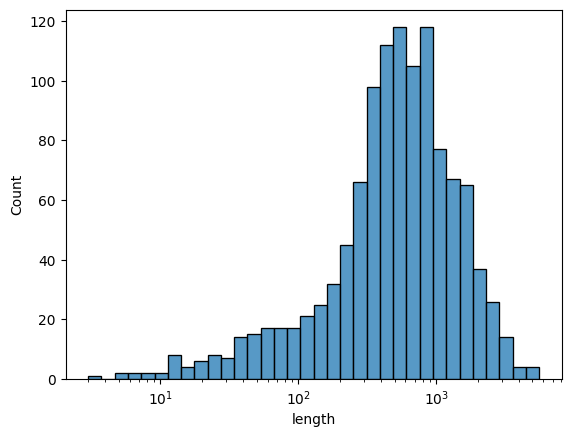

In [49]:
sns.histplot(merged_df["length"], log_scale=True)

In [50]:
merged_df.sort_values('length').head(20)

,title,image_description,keywords,category,ocr,length
slug,,,,,,
apache-netbeans.mirror,Apache NetBeans,The screenshot displays the Apache NetBeans ID...,"[Apache NetBeans, Java, code editor, autocompl...",code editor,```,3
supertuxkart,SuperTuxKart,The screenshot shows a third-person view from ...,"[SuperTuxKart, go-kart, START gate, beach trac...",game,START,5
hydra.mirror,hydra,The screenshot displays two overlapping window...,"[hydra.mirror, pink window, black terminal-lik...",other,[...],5
weylus.mirror,Weylus,The screenshot shows a tablet device mounted b...,"[Weylus, tablet, laptop, stylus, handwriting, ...",media editing,Weylus,6
node-red-low-code.mirror,Node-RED,The screenshot displays a simplified diagram w...,"[Node-RED, flowchart, data flow, JSON, nodes, ...",productivity/project tools,{ ... },7
zerotier.mirror,ZeroTier,The screenshot displays a graphical interface ...,"[ZeroTier, network diagram, toggle switch, dev...",system utilities,ZEROTIER,8
atom.mirror,Atom,The screenshot shows the Atom text editor with...,"[Atom, game.js, JavaScript, React, JSX, code e...",code editor,# game.js,9
geany.mirror,Geany,The screenshot shows the Geany text editor wit...,"[Geany, editor.c, C programming, source code, ...",code editor,# editor.c,10
arduino-ide.mirror,Arduino IDE,The screenshot shows the Arduino IDE interface...,"[Arduino IDE, Blink.ino, setup(), loop(), digi...",code editor,# Blink.ino,11


In [51]:
merged_df.sort_values('length').tail(20)

,title,image_description,keywords,category,ocr,length
slug,,,,,,
iedexplorer,IEDExplorer,The screenshot shows the IEDExplorer applicati...,"[IEDExplorer, IEC61850, test tool, localhost, ...",database tools,# IEDExplorer - IEC61850 Test tool Ver. 0.1\n\...,3026
perfview.mirror,PerfView,The screenshot displays the PerfView applicati...,"[PerfView, CPU Stacks, performance analysis, m...",system utilities,# PerfView - CPU Stacks Analysis\n\n## Metadat...,3035
goodbyedpi.mirror,GoodbyeDPI,The screenshot displays a terminal window show...,"[goodbyedpi.exe, terminal, command line, help ...",terminal,Usage: goodbyedpi.exe [OPTION...]\n\n-p ...,3048
areca,Areca Backup,The screenshot displays the Areca Backup appli...,"[Areca Backup, backup software, file list, fil...",system utilities,# Areca Backup Interface\n\n## Left Pane (Tree...,3131
msgviewer,MsgViewer,"The screenshot shows a window titled ""MsgViewe...","[MsgViewer, Microsoft Office Outlook 2003, ema...",email app,# Willkommen bei Microsoft Office Outlook 2003...,3276
gns-3,GNS3,The screenshot displays a network topology dia...,"[GNS3, network topology, routers, switches, OS...",system utilities,# Network Topology Diagram (GNS3)\n\n## Data C...,3284
spyder.mirror,spyder,The screenshot displays the Spyder IDE interfa...,"[Spyder, Python, IDE, plot_example.py, cubic.p...",code editor,"```python\n# plot_example.py\n\n""""""\nPlot a te...",3308
ffftp.mirror,FFFTP,"The screenshot displays the FFFTP application,...","[FFFTP, FTP client, file transfer, local files...",file manager,# FFFTP - File Transfer Client\n\n## Local Pan...,3333
c-total,C-Total,The screenshot displays the C-Total v2.0.0 app...,"[C-Total, firewall, network rules, Windows, ad...",system utilities,# C-Total v2.0.0\n\n## Reglas generales de RED...,3451


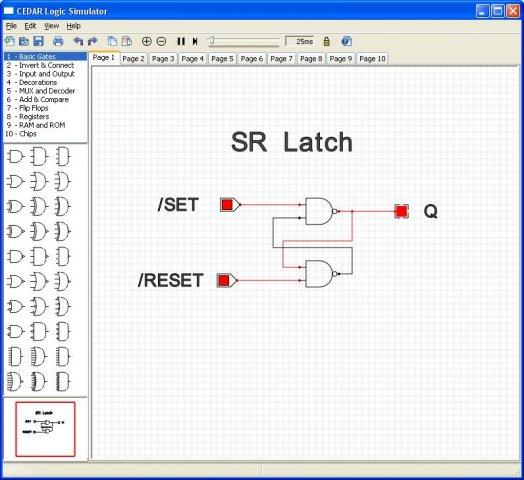

# cedarlogic

## Image Description

The screenshot displays the CEDAR Logic Simulator application window. The main canvas shows a digital logic circuit labeled "SR Latch", composed of two NOR gates connected in a feedback configuration. Inputs labeled "/SET" and "/RESET" are connected to the respective gates, and an output labeled "Q" is shown. Red square indicators appear at the input and output points. On the left sidebar, a list of logic gate icons is visible under categories such as “Basic Gates”, “Input & Output”, and “Registers”. At the bottom left, a selected component labeled “SR Latch” is highlighted with its symbol and pin layout. The top menu bar includes File, Edit, View, and Help options, along with page tabs from Page 1 to Page 10.


## OCR

# CEDAR Logic Simulator

## SR Latch Circuit

- **Inputs**: `/SET`, `/RESET`
- **Output**: `Q`
- **Configuration**: Two NOR gates in feedback loop
- **Indicators**: Red square indicators at input and output points

---

## Sidebar: Component Library

### Categories:
1. Basic Gates
2. Input & Output
3. Decorations
4. MUX and Decoder
5. Add & Compare
6. Flip Flops
7. Registers
8. RAM and ROM
9. Chips

> Selected component: **SR Latch** (symbol and pin layout shown)

---

## Top Menu Bar

- File
- Edit
- View
- Help

## Page Tabs

Page 1 | Page 2 | Page 3 | Page 4 | Page 5 | Page 6 | Page 7 | Page 8 | Page 9 | Page 10

---

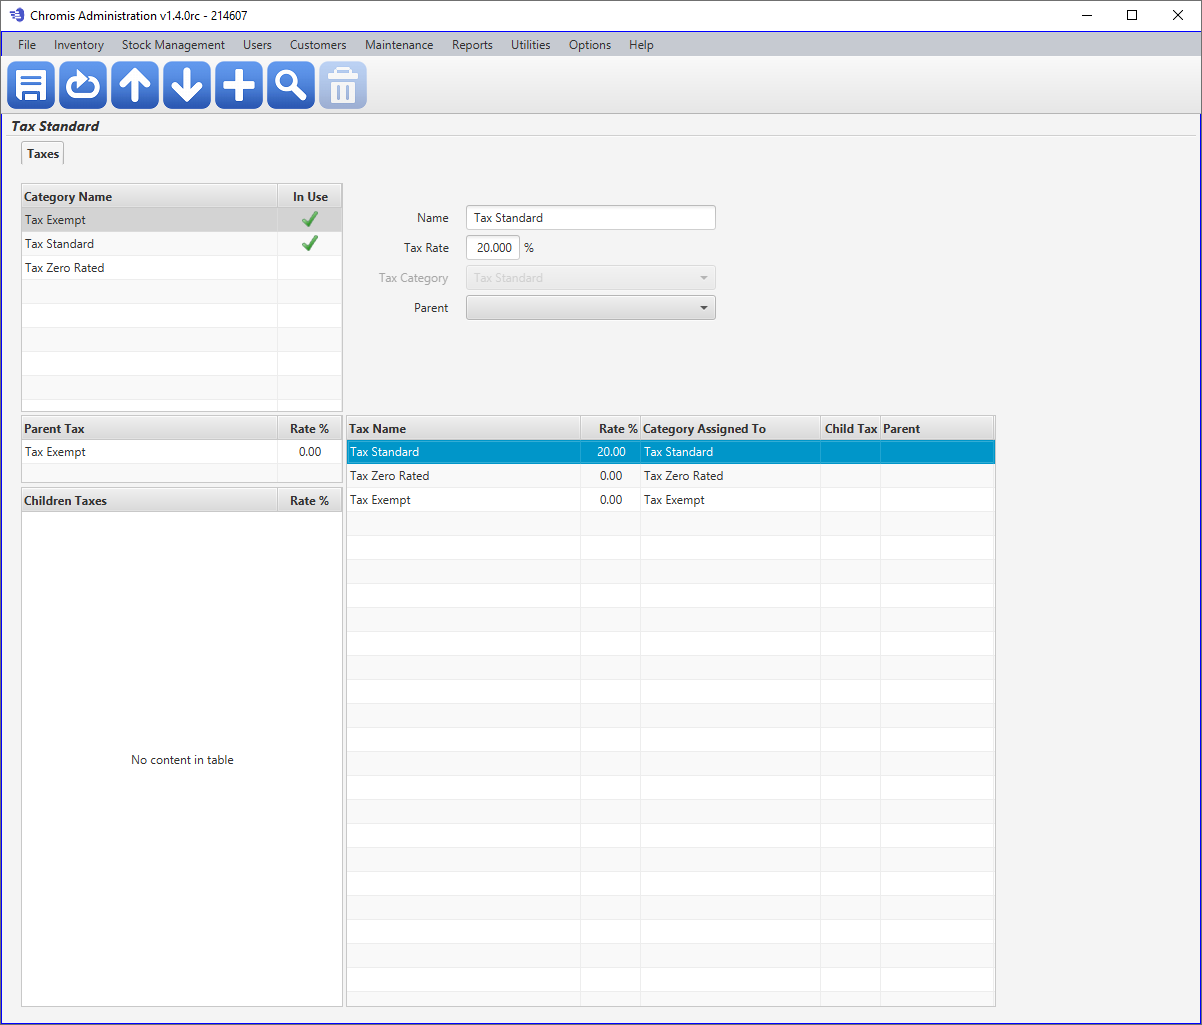

# chromispos

## Image Description

The screenshot displays the "Chromis Administration v1.4.0rc" application interface, specifically focused on tax configuration under the "Tax Standard" section. The window contains a menu bar with options such as File, Inventory, Stock Management, Users, Customers, Maintenance, Reports, Utilities, Options, and Help. Below the menu are toolbar icons for actions like refresh, move up/down, add, search, and delete.

On the left, a list of tax categories ("Tax Exempt", "Tax Standard", "Tax Zero Rated") is shown with an "In Use" indicator (green checkmark) for "Tax Exempt" and "Tax Standard". A panel in the center displays editable fields: "Name" set to "Tax Standard", "Tax Rate" set to "20.000 %", "Tax Category" dropdown set to "Tax Standard", and "Parent" dropdown empty.

Below that, a table titled "Tax Name", "Rate %", "Category Assigned To", "Child Tax", and "Parent" shows three rows: "Tax Standard" at 20.00%, "Tax Zero Rated" at 0.00%, and "Tax Exempt" at 0.00%. Another panel labeled "

## OCR

# Chromis Administration v1.4.0rc

## Menu Bar
- File
- Inventory
- Stock Management
- Users
- Customers
- Maintenance
- Reports
- Utilities
- Options
- Help

## Toolbar Icons
- Refresh
- Move Up
- Move Down
- Add
- Search
- Delete

## Tax Categories (Left Panel)
| Category Name     | In Use |
|-------------------|--------|
| Tax Exempt        | ✔      |
| Tax Standard      | ✔      |
| Tax Zero Rated    |        |

## Edit Panel (Center)
- **Name**: Tax Standard
- **Tax Rate**: 20.000 %
- **Tax Category**: Tax Standard
- **Parent**: [empty]

## Tax Table
| Tax Name         | Rate % | Category Assigned To | Child Tax | Parent |
|------------------|--------|----------------------|-----------|--------|
| Tax Standard     | 20.00  | Tax Standard         |           |        |
| Tax Zero Rated   | 0.00   | Tax Zero Rated       |           |        |
| Tax Exempt       | 0.00   | Tax Exempt           |           |        |

## Children Taxes Panel
> No content in table

---

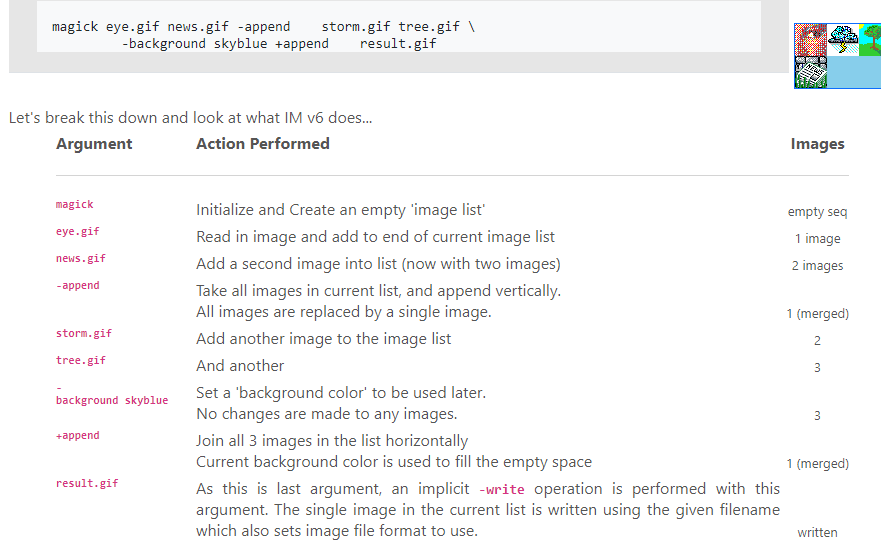

# imagemagick.mirror

## Image Description

The screenshot displays a webpage or documentation interface for ImageMagick, showing a command-line example: `magick eye.gif news.gif -append storm.gif tree.gif \ -background skyblue +append result.gif`. Below the command, there is a table titled “Let’s break this down and look at what IM v6 does...” that explains each argument and its corresponding action performed. The table includes columns labeled “Argument,” “Action Performed,” and “Images,” detailing how each part of the command manipulates image files. On the right side, small preview thumbnails of images are visible under the “Images” column, corresponding to the steps in the process.


## OCR

magick eye.gif news.gif -append storm.gif tree.gif \
-background skyblue +append result.gif

Let’s break this down and look at what IM v6 does...

| Argument           | Action Performed                                                                 | Images        |
|--------------------|----------------------------------------------------------------------------------|---------------|
| magick             | Initialize and Create an empty 'image list'                                      | empty seq     |
| eye.gif            | Read in image and add to end of current image list                               | 1 image       |
| news.gif           | Add a second image into list (now with two images)                               | 2 images      |
| -append            | Take all images in current list, and append vertically. All images are replaced by a single image. | 1 (merged)    |
| storm.gif          | Add another image to the image list                                              | 2             |
| tree.gif           | And another                                                                      | 3             |
| -background skyblue| Set a ‘background color’ to be used later. No changes are made to any images.    | 3             |
| +append            | Join all 3 images in the list horizontally. Current background color is used to fill the empty space | 1 (merged)    |
| result.gif         | As this is last argument, an implicit -write operation is performed with this argument. The single image in the current list is written using the given filename which also sets image file format to use. | written       |

---

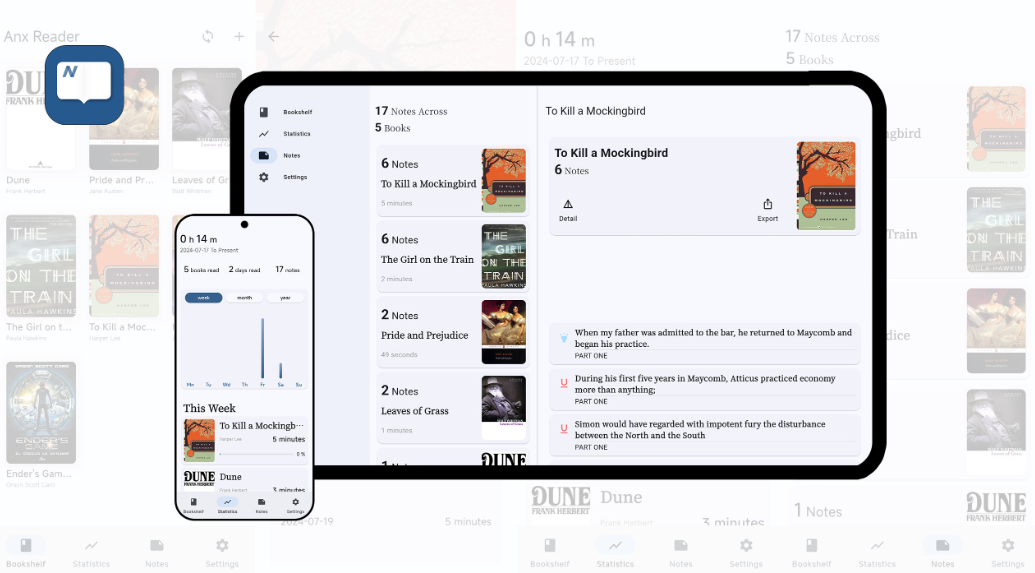

# anx-reader.mirror

## Image Description

The screenshot displays the Anx Reader application interface, showing a bookshelf view with multiple book covers including "Dune", "Pride and Prejudice", "Leaves of Grass", "The Girl on the Train", and "To Kill a Mockingbird". A central panel highlights "To Kill a Mockingbird" with 6 notes associated with it, displaying excerpts such as “When my father was admitted to the bar...” and “During his first five years in Maycomb...”. On the left, a mobile-style mockup shows reading statistics: “0 h 14 m”, “5 books read”, “2 days read”, “17 notes”, and a weekly chart. The top of the window indicates “17 Notes Across 5 Books”. Navigation tabs for Bookshelf, Statistics, Notes, and Settings are visible.


## OCR

# Anx Reader

## Bookshelf
- Dune
- Pride and Prejudice
- Leaves of Grass
- The Girl on the Train
- To Kill a Mockingbird

## 17 Notes Across 5 Books

### To Kill a Mockingbird
**6 Notes**

> When my father was admitted to the bar, he returned to Maycomb and began his practice.  
> PART ONE

> During his first five years in Maycomb, Atticus practiced economy more than anything;  
> PART ONE

> Simon would have regarded with impotent fury the disturbance between the North and the South  
> PART ONE

---

## Reading Statistics (Mobile View)

- **0 h 14 m** (2024-07-17 To Present)
- 5 books read
- 2 days read
- 17 notes

### This Week
- To Kill a Mockingbird — 5 minutes
- Dune — 3 minutes

---

## Navigation Tabs
- Bookshelf
- Statistics
- Notes
- Settings

---

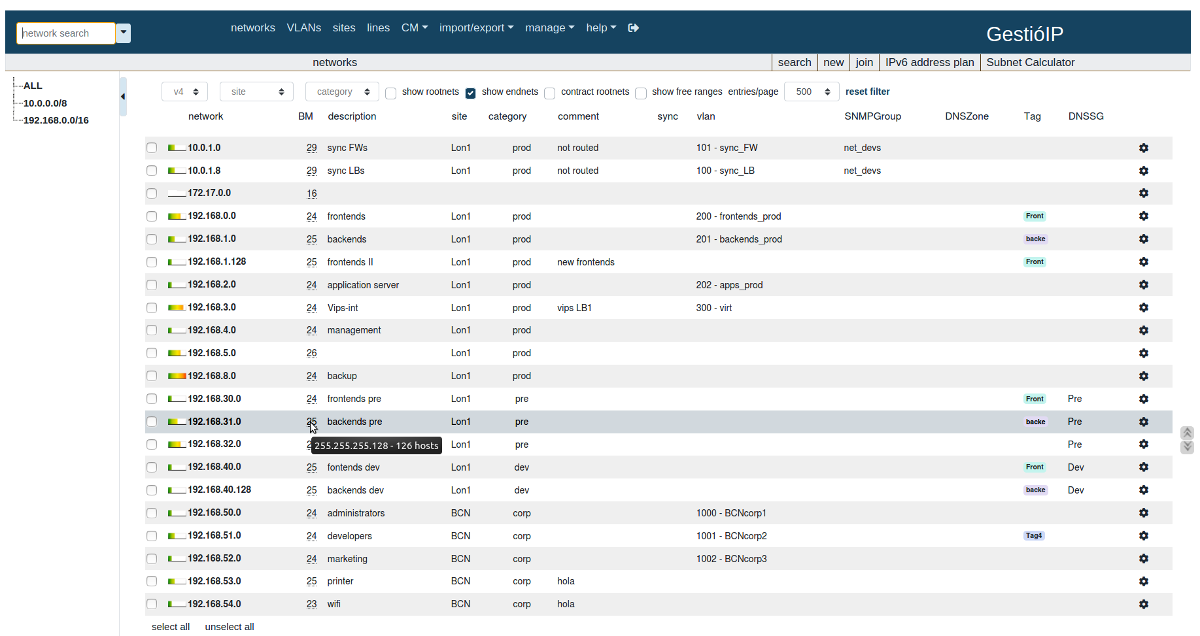

# gestioip

## Image Description

The screenshot displays the GestioIP IP address management interface. The main view is a table listing network segments with columns for network, BM (bitmask), description, site, category, comment, sync, vlan, SNMPGroup, DNSZone, Tag, and DNSSG. Each row represents a network range, such as 192.168.0.0/24 or 10.0.1.0/24, with associated metadata like “frontends”, “backends”, or “management”. Some rows are highlighted or have tooltips indicating host ranges (e.g., “255.255.255.128 - 126 hosts”). The top menu includes tabs like networks, VLANs, sites, lines, CM, import/export, manage, and help. A “network search” dropdown is visible on the left, and filtering options such as “show rootnets” and “show endnets” are present above the table.


## OCR

# GestioIP

## Networks Table

| network        | BM  | description       | site | category | comment         | sync | vlan           | SNMPGroup | DNSZone | Tag  | DNSSG |
|----------------|-----|-------------------|------|----------|-----------------|------|----------------|-----------|---------|------|-------|
| 10.0.1.0       | 29  | sync FWs          | Lon1 | prod     | not routed      |      | 101 - sync_FW  | net_devs  |         |      |       |
| 10.0.1.8       | 29  | sync LBs          | Lon1 | prod     | not routed      |      | 100 - sync_LB  | net_devs  |         |      |       |
| 172.17.0.0     | 19  |                   |      |          |                 |      |                |           |         |      |       |
| 192.168.0.0    | 24  | frontends         | Lon1 | prod     |                 |      | 200 - frontends_prod |         | Front |      |       |
| 192.168.1.0    | 25  | backends          | Lon1 | prod     |                 |      | 201 - backends_prod |         | backe |      |       |
| 192.168.1.128  | 25  | frontends II      | Lon1 | prod     | new frontends   |      |                |           | Front |      |       |
| 192.168.2.0    | 24  | application server| Lon1 | prod     |                 |      | 202 - apps_prod |         |       |      |       |
| 192.168.3.0    | 24  | Vips-int          | Lon1 | prod     | vips LB1        |      | 300 - virt     |           |       |      |       |
| 192.168.4.0    | 24  | management        | Lon1 | prod     |                 |      |                |           |       |      |       |
| 192.168.5.0    | 26  |                   | Lon1 | prod     |                 |      |                |           |       |      |       |
| 192.168.8.0    | 24  | backup            | Lon1 | prod     |                 |      |                |           |       |      |       |
| 192.168.30.0   | 24  | frontends pre     | Lon1 | pre      |                 |      |                |           | Front | Pre  |       |
| 192.168.31.0   | 25  | backends pre      | Lon1 | pre      |                 |      |                |           | backe | Pre  |       |
| 192.168.32.0   | 25  | 255.255.255.128 - 126 hosts | Lon1 | pre      |                 |      |                |           |       |      |       |
| 192.168.40.0   | 24  | frontends dev     | Lon1 | dev      |                 |      |                |           | Front | Dev  |       |
| 192.168.40.128 | 25  | backends dev      | Lon1 | dev      |                 |      |                |           | backe | Dev  |       |
| 192.168.50.0   | 24  | administrators    | BCN  | corp     |                 |      | 1000 - BCNcorp1 |         |       |      |       |
| 192.168.51.0   | 24  | developers        | BCN  | corp     |                 |      | 1001 - BCNcorp2 |         | Tag4  |      |       |
| 192.168.52.0   | 24  | marketing         | BCN  | corp     |                 |      | 1002 - BCNcorp3 |         |       |      |       |
| 192.168.53.0   | 25  | printer           | BCN  | corp     | hola            |      |                |           |       |      |       |
| 192.168.54.0   | 23  | wifi              | BCN  | corp     | hola            |      |                |           |       |      |       |

## Top Menu

- networks
- VLANs
- sites
- lines
- CM
- import/export
- manage
- help

## Filters

- show rootnets
- show endnets
- contract rootnets
- show free ranges
- entries/page: 500
- reset filter

## Sidebar

- network search
- ALL
- 10.0.0.0/8
- 192.168.0.0/16

## Actions

- select all
- unselect all

---

In [57]:
for slug in merged_df.sample(5).index:
    view_results(slug)
    display(Markdown("---"))

In [58]:
def add_image(example):
    image_path = f'../data/images/{example["slug"]}.png'
    try:
        img = Image.open(image_path)
        # Convert to RGB if needed (handles RGBA, grayscale, etc.)
        if img.mode != 'RGB':
            img = img.convert('RGB')
        return {"image": img}
    except Exception as e:
        print(f"Error loading image for {example['slug']}: {e}")
        return {"image": None}

dataset = Dataset.from_pandas(merged_df.query("length >= 30").query("length <= 4500").reset_index()).rename_column('length', 'ocr_length')
dataset = dataset.map(add_image)

Map: 100%|██████████████████████████████████████████████████████████████████████████████| 1118/1118 [00:21<00:00, 51.57 examples/s]


In [ ]:
dataset.push_to_hub("Vokturz/sourceforge-app-screenshots-ocr")

Map: 100%|████████████████████████████████████████████████████████████████████████████| 1118/1118 [00:00<00:00, 3299.06 examples/s]

Creating parquet from Arrow format: 100%|████████████████████████████████████████████████████████████| 2/2 [00:00<00:00, 10.35ba/s]
Processing Files (0 / 0): |                                                                           |  0.00B /  0.00B            
Processing Files (0 / 1):  62%|███████████████████████████████████████████▊                           | 84.0MB /  136MB, 84.0MB/s  
Processing Files (0 / 1):  62%|████████████████████████████████████████████▏                          | 84.5MB /  136MB, 70.4MB/s  
Processing Files (0 / 1):  64%|█████████████████████████████████████████████▏                         | 86.7MB /  136MB, 61.9MB/s  
Processing Files (0 / 1):  65%|██████████████████████████████████████████████                         | 88.2MB /  136MB, 55.1MB/s  
Processing Files (0 / 1):  66%|████████████████████████████████████████████